In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
steam = pd.read_csv("../Data/Cleaned/steam.csv")

### Question 1

In [3]:
steam["Genres"].value_counts()

Genres
Casual,Indie                                                 6912
Action,Indie                                                 5802
Action,Adventure,Indie                                       5259
Adventure,Indie                                              4422
Adventure,Casual,Indie                                       3691
                                                             ... 
Adventure,Simulation,Sports,Early Access                        1
Action,Indie,RPG,Simulation,Strategy,Free To Play               1
Action,Adventure,Casual,Racing,RPG,Sports                       1
Action,Casual,RPG,Simulation,Sports,Strategy,Early Access       1
Action,Simulation,Strategy,Free To Play,Early Access            1
Name: count, Length: 2922, dtype: int64

In [4]:
genres = steam.copy()

In [5]:
genres["Genres"] = genres["Genres"].str.split(",")

In [6]:
genres = genres.explode("Genres")

In [7]:
genre_counts = (
    genres["Genres"]
    .value_counts()
    .head(15)
)

genre_counts

Genres
Indie                    82884
Casual                   51671
Action                   47344
Adventure                46293
Simulation               24911
Strategy                 23058
RPG                      21577
Free To Play             12605
Early Access             11572
Sports                    4970
Racing                    4169
Massively Multiplayer     2596
Utilities                 1091
Design & Illustration      584
Animation & Modeling       484
Name: count, dtype: int64

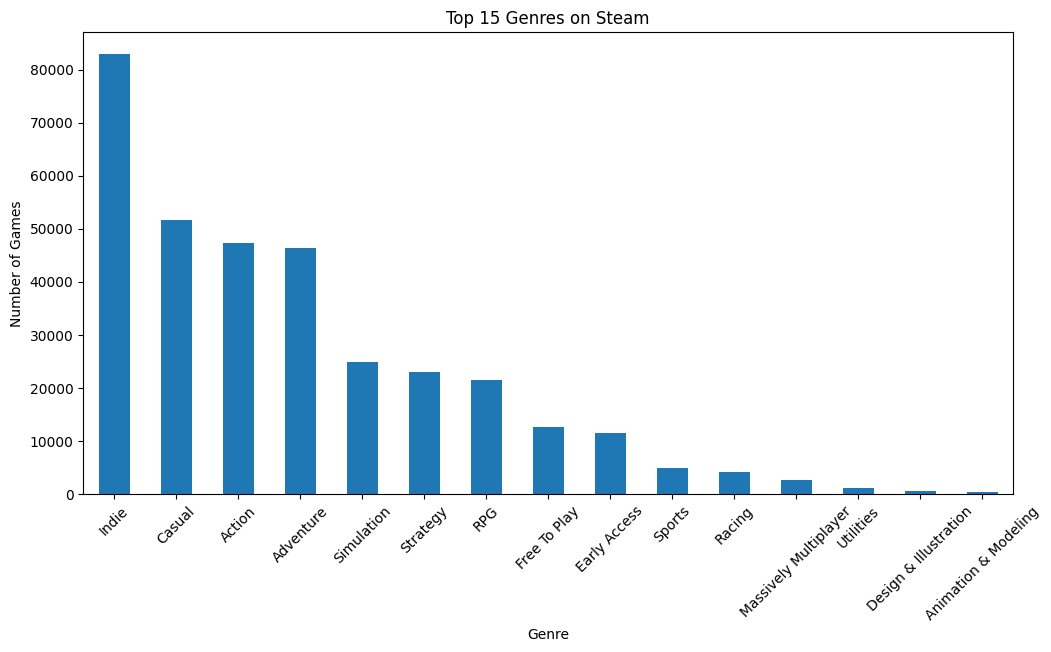

In [8]:
plt.figure(figsize=(12,6))

genre_counts.plot(kind="bar")

plt.title("Top 15 Genres on Steam")
plt.xlabel("Genre")
plt.ylabel("Number of Games")

plt.xticks(rotation=45)

plt.savefig("../Images/Genre Analysis/top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

### Question 2

In [11]:
genres["Genres"] = genres["Genres"].str.strip()

In [12]:
genres = genres[
    (genres["Total Reviews"] > 0) &
    (genres["Genres"].notna())
]

In [13]:
genre_reviews = (
    genres
    .groupby("Genres")["Review Score %"]
    .mean()
    .sort_values(ascending=False)
)

In [14]:
genre_counts = genres["Genres"].value_counts()

valid_genres = genre_counts[genre_counts >= 100].index

In [15]:
genre_reviews = (
    genres[genres["Genres"].isin(valid_genres)]
    .groupby("Genres")["Review Score %"]
    .mean()
    .sort_values(ascending=False)
)

In [16]:
top_reviewed = genre_reviews.head(15)

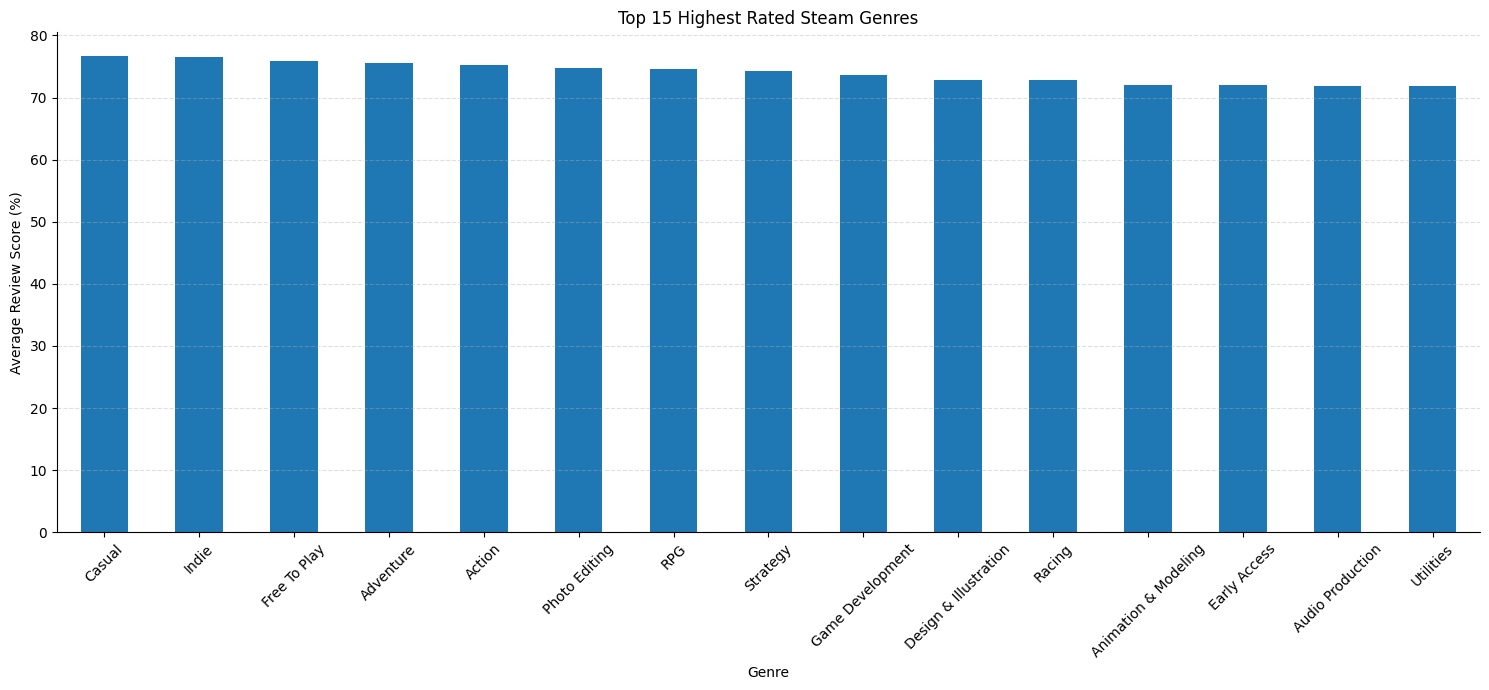

In [17]:
fig, ax = plt.subplots(figsize=(15,7))

top_reviewed.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 15 Highest Rated Steam Genres")
ax.set_xlabel("Genre")
ax.set_ylabel("Average Review Score (%)")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/highest_rated_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Question 3

In [18]:
engagement = genres.copy()

In [19]:
engagement = engagement[
    (engagement["Average playtime forever"] > 0) &
    (engagement["Genres"].notna())
]

In [20]:
genre_counts = engagement["Genres"].value_counts()

valid = genre_counts[genre_counts >= 100].index

engagement = engagement[
    engagement["Genres"].isin(valid)
]

In [21]:
genre_playtime = (
    engagement
    .groupby("Genres")["Average playtime forever"]
    .mean()
    .sort_values(ascending=False)
)

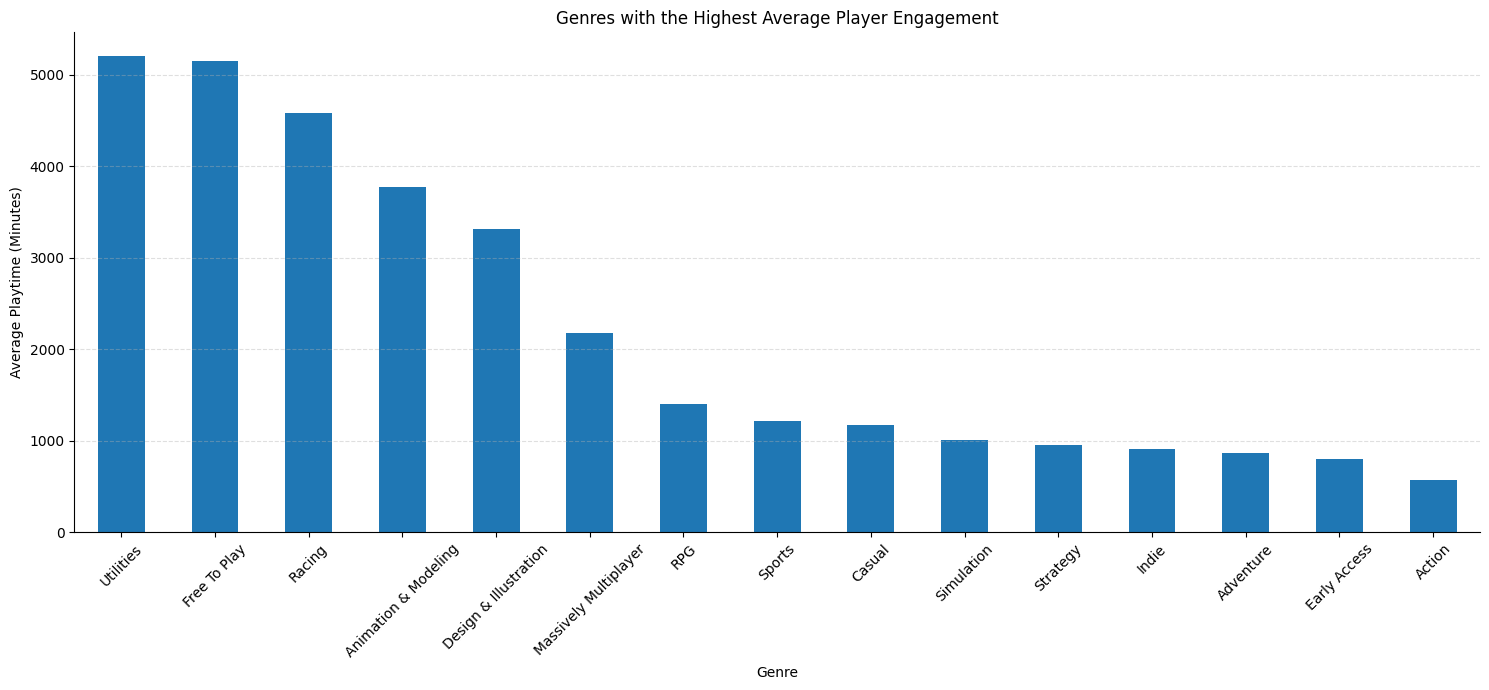

In [22]:
fig, ax = plt.subplots(figsize=(15,7))

genre_playtime.head(15).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Genres with the Highest Average Player Engagement")
ax.set_xlabel("Genre")
ax.set_ylabel("Average Playtime (Minutes)")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/highest_player_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Question 4

In [23]:
genre_count = genres["Genres"].value_counts()

genre_rating = (
    genres
    .groupby("Genres")["Review Score %"]
    .mean()
)

comparison = pd.DataFrame({
    "Game Count": genre_count,
    "Average Review": genre_rating
})

In [24]:
comparison = comparison[
    comparison["Game Count"] >= 100
]

In [25]:
comparison.sort_values(
    by="Game Count",
    ascending=False,
    inplace=True
)

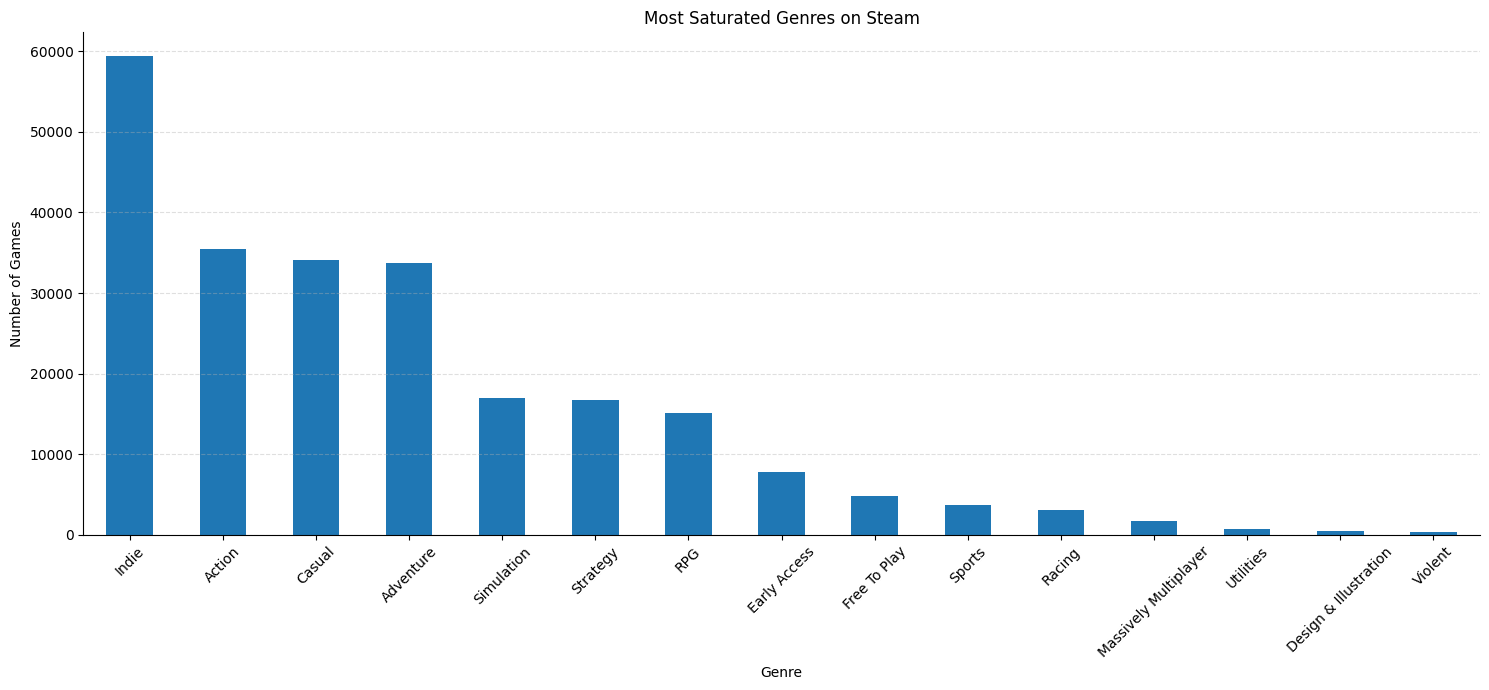

In [26]:
fig, ax = plt.subplots(figsize=(15,7))

comparison["Game Count"].head(15).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Most Saturated Genres on Steam")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Games")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/most_saturated_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()